# **Time-Series Forecasting of Agricultural Production**

Dataset: Production_Crops_Livestock_E_All_Data.csv

source: https://www.fao.org/faostat/

1. Import Required Libraries:

In [1]:
import pandas as pd # this data frame used for reading, filtering, and reshaping tabular data
import numpy as np # numerical operations
import matplotlib.pyplot as pltt # used for plotting the time series
import matplotlib.ticker as tic
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2. Loading the FAOSTAT Dataset

In [2]:
# storing the location of your CSV file
file_path = "Production_Crops_Livestock_E_All_Data.csv"
df = pd.read_csv(file_path)
print(df.shape)
df.head()

/tmp/ipykernel_6043/3755963969.py:3: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(78974, 201)


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,...,NaN,36462.0,A,NaN,37000.0,A,NaN,39794.00,I,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,...,NaN,1742.0,A,NaN,1810.8,A,NaN,1741.90,E,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,...,NaN,63515.0,A,NaN,67000.0,A,NaN,69315.64,I,NaN
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,NaN,...,NaN,25403.0,E,NaN,25439.0,E,NaN,25400.00,E,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,...,NaN,704.0,E,NaN,704.0,E,NaN,704.30,E,NaN


In [3]:
#countries = ["India","United Kindom","United States of America"]
country = "India"
crop = "Wheat"
df_filtered = df[
    (df["Area"] == country) &
    #(df["Area"].isin(countries))&
    (df["Item"] == crop) &
    (df["Element"] == "Production")]
df_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
25786,100,'356,India,15,'0111,Wheat,5510,Production,t,10997000.0,...,NaN,107742070.0,A,NaN,1.105537e+08,A,NaN,113292368.0,A,NaN


In [4]:
Unit = df_filtered["Unit"].iloc[0]

4. Data Cleaning

In [5]:
year_columns = [col for col in df_filtered.columns if col.startswith('Y') and not (col.endswith('N') or col.endswith('F'))]
ts = df_filtered[year_columns].T
ts.index = [int(''.join(filter(str.isdigit, year))) for year in year_columns]
ts.columns = ["Production"]
ts.head()

,Production
1961,10997000.0
1962,12072000.0
1963,10776000.0
1964,9853000.0
1965,12257000.0


Converting to Time Series Format

In [6]:
# The 'Year' column has already been converted to a datetime index in the previous step.
# Therefore, the following two lines are redundant and cause a KeyError.
ts["Production"] = pd.to_numeric(ts["Production"],errors="coerce")

# Removing missing values
ts = ts.dropna()

# Removing zero or negative values
ts = ts[ts["Production"] > 0]

# Converting to datetime
ts.index = pd.to_datetime(ts.index, format="%Y")

# Sorting chronologically
ts = ts.sort_index()
print("Cleaned Data Preview:")
print(ts.head())
print("Total Observations:", len(ts))


Cleaned Data Preview:
            Production
1961-01-01  10997000.0
1962-01-01  12072000.0
1963-01-01  10776000.0
1964-01-01   9853000.0
1965-01-01  12257000.0
Total Observations: 64


Exploratory Data Analysis (EDA)

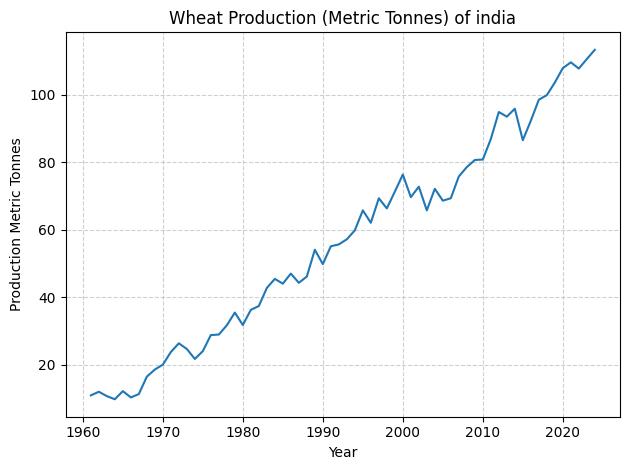

In [7]:
# plotting the EDA
ts["Production_Million"] = ts["Production"]/1000000
pltt.figure()
pltt.plot(ts.index, ts["Production_Million"])
pltt.title("Wheat Production (Metric Tonnes) of india")
pltt.xlabel("Year")
pltt.ylabel("Production Metric Tonnes")
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))
pltt.grid(True, linestyle='--', alpha=0.6)
pltt.tight_layout()
pltt.show()

Training and Testing data

In [10]:
#Training-testing 80% train, 20% test
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 51
Test size: 13


Baseline model/ Naïve forecasting:


In [11]:
#Baseline forcating
baseline = np.repeat(train["Production"].iloc[-1],len(test))

#Storing the results in DataFrame
baseline_df = pd.DataFrame({
    "Actual": test["Production"],
    "Baseline Forecast": baseline}, index=test.index)

/tmp/ipykernel_6043/1722645969.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


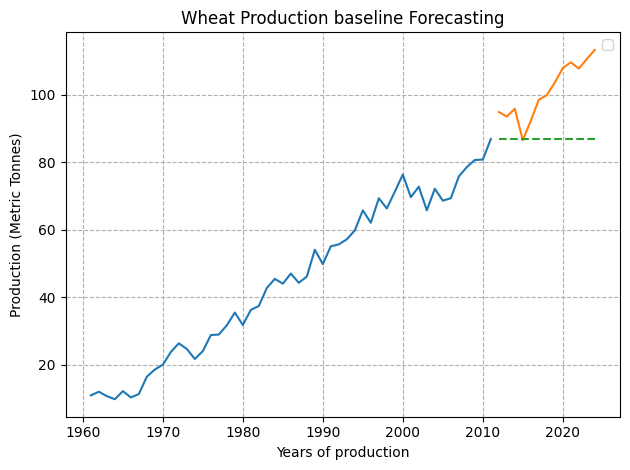

In [12]:
# plotting the Training, Actual, and Baseline /Naïve Forecasting
pltt.figure()
pltt.plot(train.index, train["Production"] / 1000000,)
pltt.plot(test.index, test["Production"] / 1000000,)
pltt.plot(test.index, baseline/ 1000000,linestyle="--")
pltt.title("Wheat Production baseline Forecasting")
pltt.xlabel("Years of production")
pltt.ylabel("Production (Metric Tonnes)")
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))
pltt.grid(True, linestyle='--')
pltt.legend()
pltt.tight_layout()
pltt.show()

/tmp/ipykernel_6043/1999296437.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


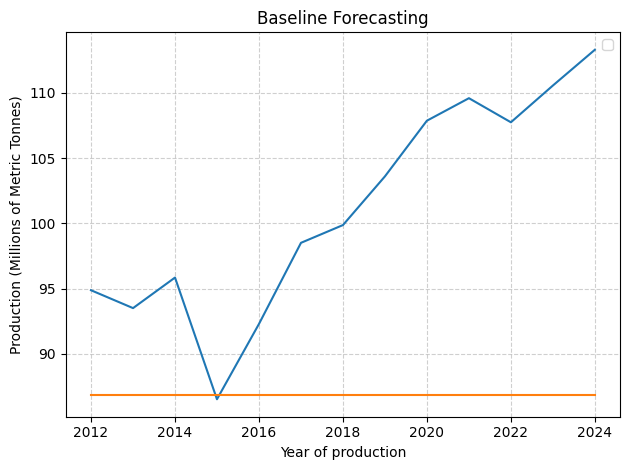

In [13]:
# plotting the Baseline forecasting
pltt.figure()
pltt.plot(baseline_df.index, baseline_df["Actual"] / 1000000)
pltt.plot(baseline_df.index, baseline_df["Baseline Forecast"] / 1000000)
pltt.title("Baseline Forecasting")
pltt.xlabel("Year of production")
pltt.ylabel("Production (Millions of Metric Tonnes)")
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))
pltt.grid(True, linestyle='--', alpha=0.6)
pltt.legend()
pltt.tight_layout()
pltt.show()

AutoRegressive intergrated Moving Average (ARIMA) Model:


In [14]:
#ARIMA require the time series to have a constant mean and variance over time.
result = adfuller(ts["Production"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ts_differ = ts["Production"].diff().dropna()
result_differ = adfuller(ts_differ)
print("ADF Statistics after differencing the data:", result_differ[0])
print("p-value after differencing the data:", result_differ[1])

ADF Statistic: 0.5223189974863071
p-value: 0.9855359074951656
ADF Statistics after differencing the data: -11.270068162289286
p-value after differencing the data: 1.5447308923906597e-20


<Figure size 1000x400 with 0 Axes>

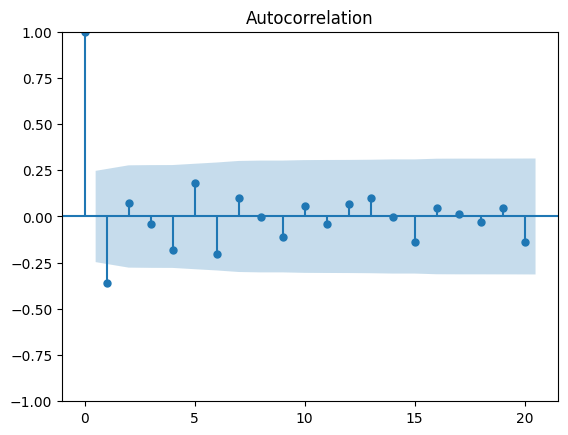

<Figure size 1000x400 with 0 Axes>

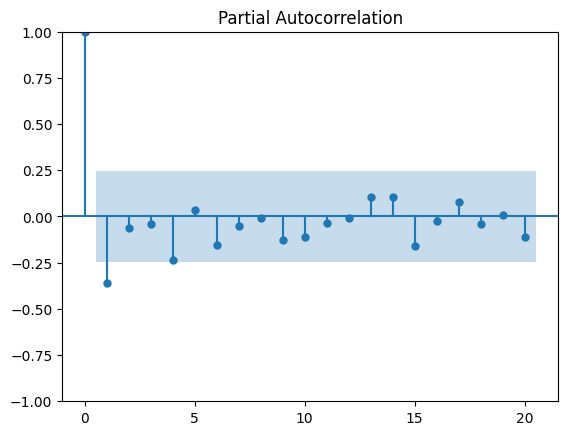

In [15]:
# ACF and PACF Plotings
#These plots to decide p and q
pltt.figure(figsize=(10,4))
plot_acf(ts_differ, lags=20)
pltt.show()

pltt.figure(figsize=(10,4))
plot_pacf(ts_differ, lags=20)
pltt.show()

In [16]:
model = ARIMA(train["Production"], order=(1,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))
forecast_million = forecast / 1_000_000

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


ARIMA Model Plotting and ACTUAL Plotting:

/tmp/ipykernel_6043/3182884176.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


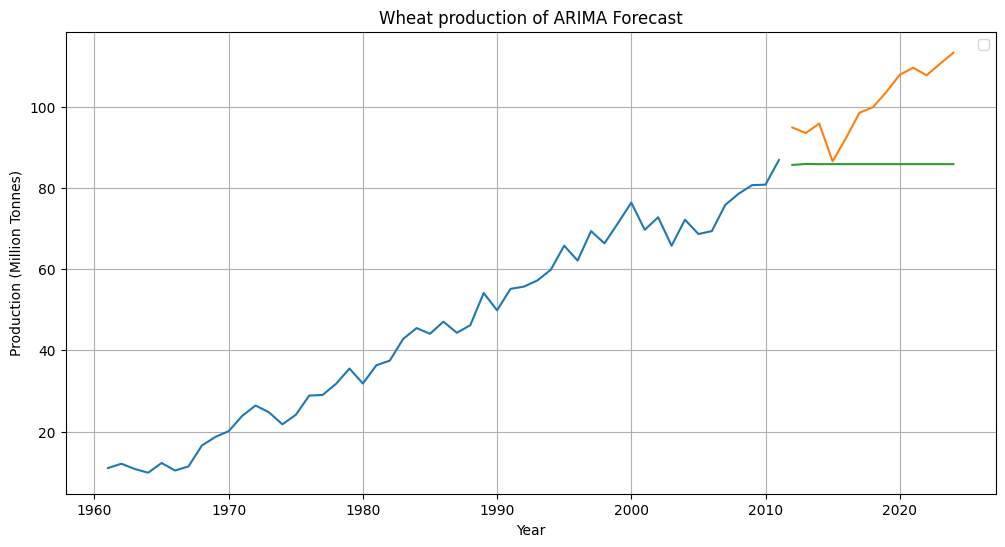

In [17]:
pltt.figure(figsize=(12,6))

pltt.plot(train.index, train["Production_Million"])
pltt.plot(test.index, test["Production_Million"])
pltt.plot(test.index, forecast_million)

pltt.title("Wheat production of ARIMA Forecast")
pltt.xlabel("Year")
pltt.ylabel("Production (Million Tonnes)")

pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))

pltt.legend()
pltt.grid(True)

pltt.show()

In [18]:
scaler = MinMaxScaler()
trained_scale = scaler.fit_transform(train[["Production"]])
tested_scale = scaler.transform(test[["Production"]])

In [19]:
def create_dataset(data, time_step=3):
    X = []
    y = []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step),0])
        y.append(data[i+time_step,0])
    return np.array(X), np.array(y)

In [20]:
# comparing the previous years
time_steps = 3
X_train, y_train = create_dataset(trained_scale, time_steps)
X_test, y_test = create_dataset(tested_scale, time_steps)

In [21]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [22]:
lstm = Sequential()
lstm.add(LSTM(50, activation='relu', input_shape=(0,1)))
lstm.add(Dense(1))
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train, y_train, epochs=50, verbose=1)
predictions = lstm.predict(X_test)
predictions = scaler.inverse_transform(predictions)
pred_million = predictions.flatten() / 1_000_000

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 991ms/step - loss: 0.3435
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3293
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3156
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3015
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2875
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2753
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2618
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2488
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2372
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2249
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2123
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2004
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1875
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1760
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1630
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━

/tmp/ipykernel_6043/1508765845.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


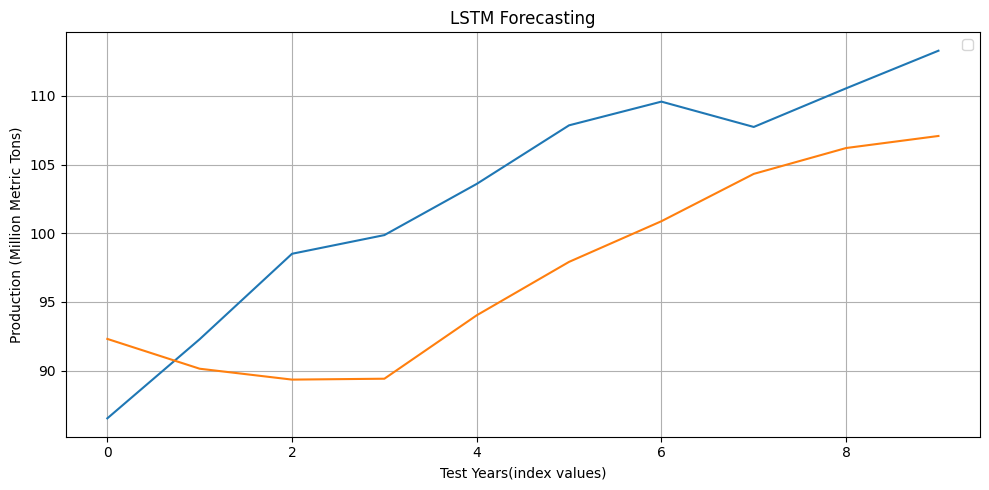

In [23]:
# Converting actual test values
y_test_val = scaler.inverse_transform(y_test.reshape(-1,1))
actual_million = y_test_val.flatten() / 1_000_000

pltt.figure(figsize=(10,5))

pltt.plot(actual_million)
pltt.plot(pred_million)

pltt.title("LSTM Forecasting")
pltt.xlabel("Test Years(index values)")
pltt.ylabel("Production (Million Metric Tons)")

pltt.ticklabel_format(style='plain', axis='y')
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))

pltt.legend()
pltt.grid(True)
pltt.tight_layout()

pltt.show()

/tmp/ipykernel_6043/2231440162.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


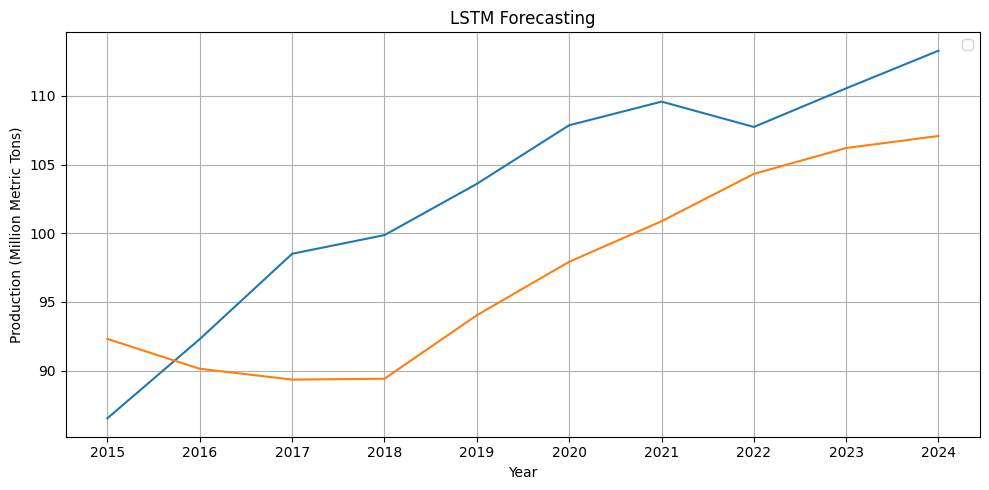

In [24]:
# Getting years matching prediction length
test_years = test.index[-len(y_test):]

# Converting scaled values back to original values
y_test_val = scaler.inverse_transform(y_test.reshape(-1,1))
actual_million = y_test_val.flatten() / 1_000_000
pltt.figure(figsize=(10,5))
pltt.plot(test_years, actual_million)
pltt.plot(test_years, pred_million)
pltt.title("LSTM Forecasting")
pltt.xlabel("Year")
pltt.ylabel("Production (Million Metric Tons)")
pltt.ticklabel_format(style='plain', axis='y')
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:,.0f}'))

pltt.legend()
pltt.grid(True)
pltt.tight_layout()

pltt.show()

In [25]:
# Baseline
baseline_rmse = np.sqrt(mean_squared_error(test["Production"], baseline))
baseline_mape = np.mean(np.abs((test["Production"] - baseline) / test["Production"])) * 100
baseline_mae = mean_absolute_error(test["Production"], baseline)

# ARIMA
arima_rmse = np.sqrt(mean_squared_error(test["Production"], forecast))
arima_mape = np.mean(np.abs((test["Production"] - forecast) / test["Production"])) * 100
arima_mae = mean_absolute_error(test["Production"], forecast)

# LSTM
actual_lstm = test["Production"].values[:len(predictions)]
lstm_rmse = np.sqrt(mean_squared_error(actual_lstm, predictions))
actual_lstm = test["Production"].values[:len(predictions)]

lstm_mape = np.mean(np.abs((actual_lstm - predictions) / actual_lstm)) * 100
lstm_mae = mean_absolute_error(actual_lstm, predictions)

# Printing Results
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAPE:", baseline_mape)
print("Baseline MAE:", baseline_mae)
print()
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)
print("ARIMA MAE:", arima_mae)
print()
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)
print("LSTM MAE:", lstm_mae)

Baseline RMSE: 16296520.219541792
Baseline MAPE: 13.570834549223118
Baseline MAE: 14261314.870000001

ARIMA RMSE: 17197867.650088787
ARIMA MAPE: 14.536064084660746
ARIMA MAE: 15238635.41290782

LSTM RMSE: 2871023.4332587393
LSTM MAPE: 8.040151575792667
LSTM MAE: 2354436.0


In [26]:
results = pd.DataFrame({

"Model":["Baseline","ARIMA","LSTM"],

"RMSE":[baseline_rmse, arima_rmse, lstm_rmse],
"MAPE":[baseline_mape, arima_mape, lstm_mape],
"MAE":[baseline_mae, arima_mae, lstm_mae]

})

print(results)

      Model          RMSE       MAPE           MAE
0  Baseline  1.629652e+07  13.570835  1.426131e+07
1     ARIMA  1.719787e+07  14.536064  1.523864e+07
2      LSTM  2.871023e+06   8.040152  2.354436e+06


      Model       RMSE
0  Baseline  16.296520
1     ARIMA  17.197868
2      LSTM   2.871023


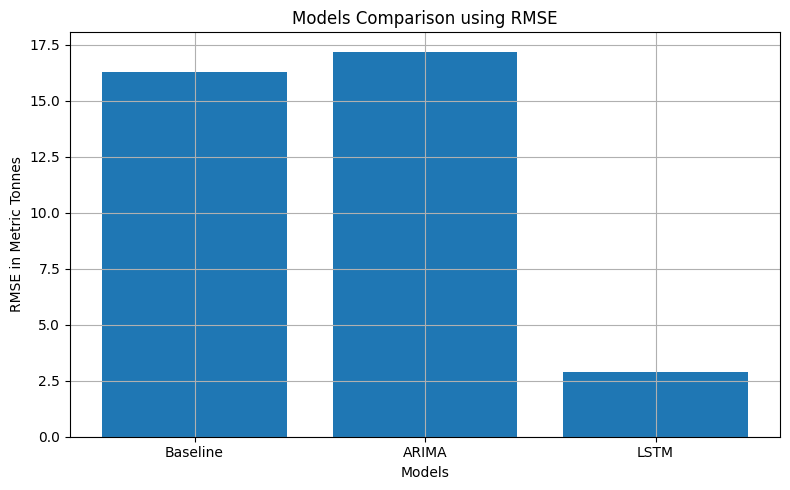

In [27]:
# Creating results dataframe of Root Mean Square Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "RMSE": [baseline_rmse/1000000, arima_rmse/1000000, lstm_rmse/1000000]
})

print(results)

# Plotting
pltt.figure(figsize=(8,5))

pltt.bar(results["Model"], results["RMSE"])

pltt.title("Models Comparison using RMSE")
pltt.xlabel("Models")
pltt.ylabel("RMSE in Metric Tonnes")

pltt.grid()
pltt.tight_layout()

pltt.show()

      Model       MAPE
0  Baseline  13.570835
1     ARIMA  14.536064
2      LSTM   8.040152


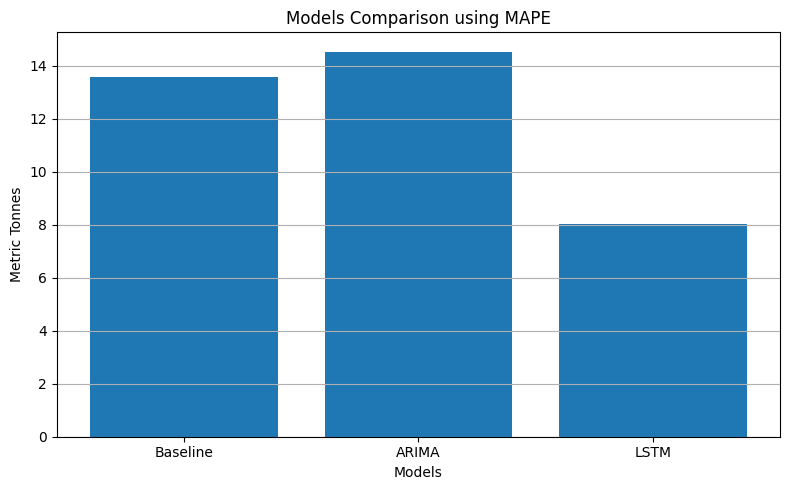

In [28]:
# Creating results dataframe of Mean Absolute Percentage Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "MAPE": [baseline_mape, arima_mape, lstm_mape]
})

print(results)

pltt.figure(figsize=(8,5))
pltt.bar(results["Model"], results["MAPE"])


pltt.title("Models Comparison using MAPE")
pltt.xlabel("Models")
pltt.ylabel("Metric Tonnes")

pltt.grid(axis='y')
pltt.tight_layout()

pltt.show()

      Model        MAE
0  Baseline  14.261315
1     ARIMA  15.238635
2      LSTM   2.354436


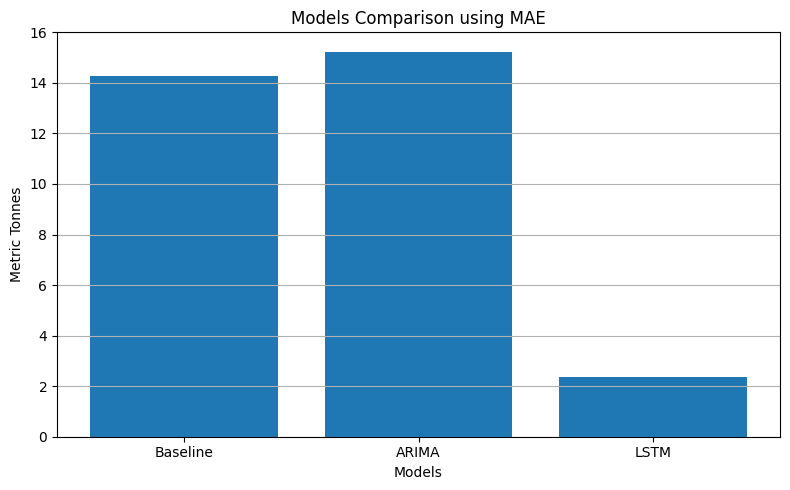

In [29]:
# Creating results dataframe Mean absolute Error
results = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "LSTM"],
    "MAE": [baseline_mae/1000000, arima_mae/1000000, lstm_mae/1000000]
})

print(results)

# Plotting
pltt.figure(figsize=(8,5))
pltt.bar(results["Model"], results["MAE"])

pltt.title("Models Comparison using MAE")
pltt.xlabel("Models")
pltt.ylabel("Metric Tonnes")

pltt.grid(axis='y')
pltt.tight_layout()

pltt.show()

Hyper parameter Tuning


In [30]:
# Hyperparameter tuning for ARIMA
p_values = [0, 2]
d_values = [0, 1]
q_values = [0, 2]

best_score = float("inf")
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train["Production"], order=(p, d, q))
                model_fit = model.fit()

                forecast = model_fit.forecast(steps=len(test))

                # RMSE
                rmse = np.sqrt(mean_squared_error(test["Production"], forecast))

                # MAE
                mae = mean_absolute_error(test["Production"], forecast)

                # MAPE
                mape = np.mean(
                    np.abs((test["Production"] - forecast) / test["Production"])
                ) * 100

                print(f"ARIMA({p},{d},{q}) -> RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%")

                # Using RMSE to selecting best model
                if rmse < best_score:
                    best_score = rmse
                    best_order = (p, d, q)

            except:
                continue

print("\nBest ARIMA Order:", best_order)
print("Best RMSE:", best_score)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

ARIMA(0,0,0) -> RMSE: 56189030.535, MAE: 55619321.989, MAPE: 54.738%
ARIMA(0,0,2) -> RMSE: 54008794.868, MAE: 52383838.845, MAPE: 51.312%
ARIMA(0,1,0) -> RMSE: 16296520.220, MAE: 14261314.870, MAPE: 13.571%
ARIMA(0,1,2) -> RMSE: 16316707.698, MAE: 14343517.725, MAPE: 13.662%
ARIMA(2,0,0) -> RMSE: 18511098.788, MAE: 16469007.728, MAPE: 15.724%
ARIMA(2,0,2) -> RMSE: 18280520.946, MAE: 15972747.648, MAPE: 15.196%
ARIMA(2,1,0) -> RMSE: 16062637.461, MAE: 14090964.949, MAPE: 13.416%
ARIMA(2,1,2) -> RMSE: 6563629.880, MAE: 6119500.562, MAPE: 5.974%

Best ARIMA Order: (2, 1, 2)
Best RMSE: 6563629.880238358


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

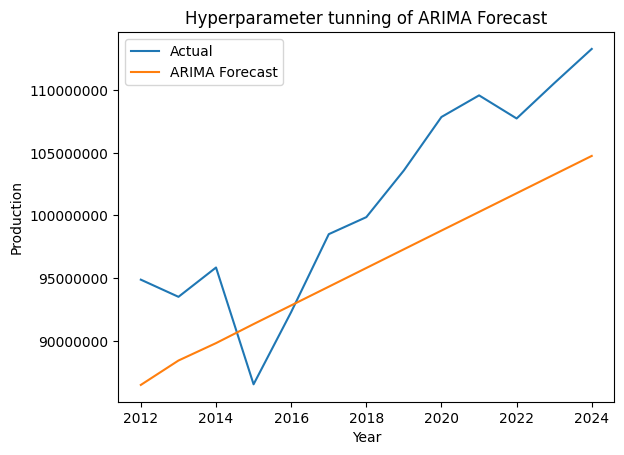

In [31]:
pltt.figure()

pltt.plot(test.index, test["Production"], label="Actual")
pltt.plot(forecast.index, forecast, label="ARIMA Forecast")

pltt.xlabel("Year")
pltt.ylabel("Production")
pltt.title("Hyperparameter tunning of ARIMA Forecast")

pltt.ticklabel_format(style='plain', axis='y')

pltt.legend()
pltt.show()

In [ ]:
# Hyperparameter tuning for LSTM
neurons_lt = [20, 50, 100]
epochs_lt = [20, 50]
batch_siz = [1, 4]

best_rmse = float("inf")
best_params = None

for neurons in neurons_lt:
    for epochs in epochs_lt:
        for batch in batch_siz:

            model = Sequential()
            model.add(LSTM(neurons, input_shape=(time_steps,1)))
            model.add(Dense(1))

            model.compile(optimizer='adam', loss='mse')

            model.fit(X_train, y_train, epochs=epochs, batch_size=batch, verbose=0)

            pred = model.predict(X_test)
            pred = scaler.inverse_transform(pred)

            # RMSE
            rmse = np.sqrt(mean_squared_error(y_test_val, pred))

            # MAE
            mae = mean_absolute_error(y_test_val, pred)

            # MAPE
            mape = np.mean(
                np.abs((y_test_val - pred) / y_test_val)
            ) * 100

            print(f"Neurons:{neurons}, Epochs:{epochs}, Batch:{batch} → RMSE:{rmse:.3f}, MAE:{mae:.3f}, MAPE:{mape:.3f}%")

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (neurons, epochs, batch)

print("\nBest LSTM Parameters:", best_params)
print("Best RMSE:", best_rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Neurons:20, Epochs:20, Batch:1 → RMSE:5597416.470, MAE:4906107.731, MAPE:4.882%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Neurons:20, Epochs:20, Batch:4 → RMSE:5316832.441, MAE:4532322.931, MAPE:4.548%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Neurons:20, Epochs:50, Batch:1 → RMSE:4875873.752, MAE:3941854.531, MAPE:4.033%


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Neurons:100, Epochs:20, Batch:4 → RMSE:5285106.529, MAE:4310398.669, MAPE:4.412%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Neurons:100, Epochs:50, Batch:1 → RMSE:6867869.090, MAE:6356359.731, MAPE:6.165%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Neurons:100, Epochs:50, Batch:4 → RMSE:4943397.368, MAE:3864982.669, MAPE:3.998%

Best LSTM Parameters: (20, 50, 1)
Best RMSE: 4875873.751596453


/tmp/ipykernel_1758/2215588812.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pltt.legend()


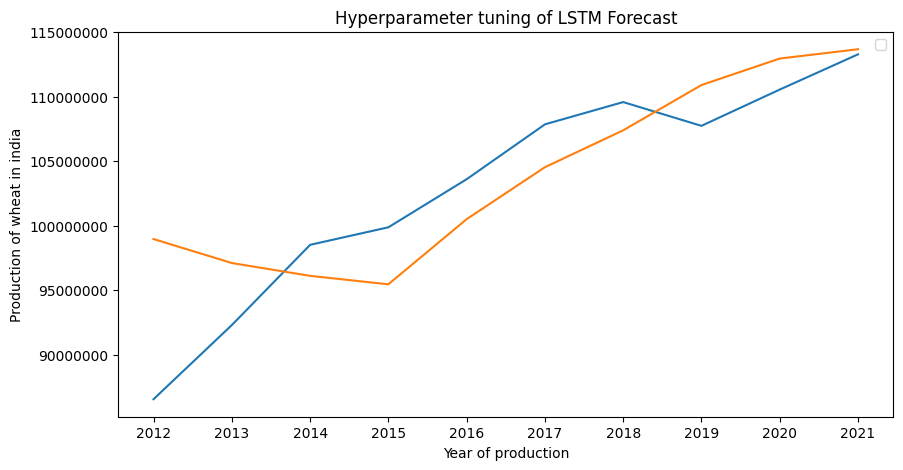

In [ ]:
y_actual = y_test_val.flatten()
y_pred = pred.flatten()

min_val = min(len(y_actual), len(y_pred))

y_actual = y_actual[:min_val]
y_pred = y_pred[:min_val]
x_axis = test.index[:min_val]

pltt.figure(figsize=(10,5))

pltt.plot(x_axis, y_actual)
pltt.plot(x_axis, y_pred)

pltt.xlabel("Year of production")
pltt.ylabel("Production of wheat in india")
pltt.title("Hyperparameter tuning of LSTM Forecast")

pltt.gca().yaxis.set_major_locator(tic.MaxNLocator(nbins=6))
pltt.gca().yaxis.set_major_formatter(tic.StrMethodFormatter('{x:.0f}'))

pltt.legend()

pltt.show()